
Wyznaczone współczynniki: a = -1125995998304714.7500, b = 562997999152362.6250


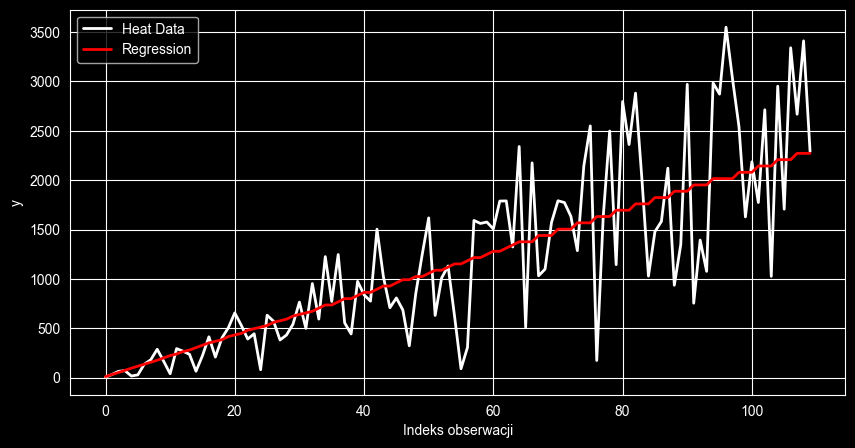


Wyznaczone współczynniki(pinv): a = 2.2311, b = 4.4621


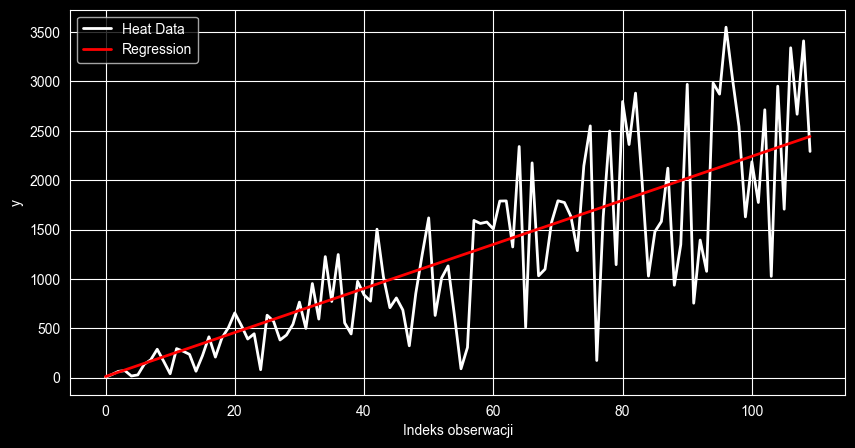

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Load dataset
# A = np.loadtxt(os.path.join('..','DATA','hald_ingredients.csv'),delimiter=',')
# b = np.loadtxt(os.path.join('..','DATA','hald_heat.csv'),delimiter=',')

df = pd.read_csv('war12.csv', sep=';', decimal=',')
A = np.column_stack((df['x1'].values, df['x2'].values))
b = df['y'].values

# Solve Ax=b using SVD
U, S, VT = np.linalg.svd(A, full_matrices=False)
x = VT.T @ np.linalg.inv(np.diag(S)) @ U.T @ b
print(f"\nWyznaczone współczynni"
      f"ki: a = {x[0]:.4f}, b = {x[1]:.4f}")


plt.figure(figsize=(10, 5))
plt.plot(b, color='white', linewidth=2, label='Heat Data')
plt.plot(A@x, 'r-', linewidth=2, label='Regression')
plt.xlabel('Indeks obserwacji')
plt.ylabel('y')
plt.legend()
plt.show()

x_s = np.linalg.pinv(A)@b # Alternative
print(f"\nWyznaczone współczynniki(pinv): a = {x_s[0]:.4f}, b = {x_s[1]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(b, color='white', linewidth=2, label='Heat Data')
plt.plot(A@x_s, 'r-', linewidth=2, label='Regression')
plt.xlabel('Indeks obserwacji')
plt.ylabel('y')
plt.legend()
plt.show()
